In [52]:
import pandas as pd

df = pd.read_csv('top2019.csv')

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

df.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


#### What is machine learning, and what is our goal here? In your own words, define the goal of machine learning (briefly). What kind of prediction could we make using this dataset? What variable seems like a good target?

Machine learning is when you use data to train a model to essentially recognize patterns and predict outputs based on the provided inputs. This is usually done by splitting data into train and test data. the train group contains inputs and outputs and the test data just inputs. when the model predicts outputs of the test data you can compare it to the actual values and assess the models accuracy. I think for this data set, any of the numerical values would be good targets. based on the upcoming questions in the worksheet, it seems I will be using danceability as my target.

#### Do some preliminary data summary analysis based on some of the skills you learned from W2.

In [53]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,0.719400,0.60462,5.280000,-6.229000,0.580000,0.127582,0.299381,0.006039,0.132792,0.490460,120.425700,201691.620000,4.0
std,0.130358,0.16975,3.295266,2.725249,0.498569,0.103008,0.255321,0.029065,0.074088,0.219144,28.740856,44213.177325,0.0
min,0.351000,0.11100,0.000000,-14.505000,0.000000,0.029000,0.005130,0.000000,0.057400,0.120000,71.105000,113000.000000,4.0
25%,0.657500,0.52000,2.000000,-7.056000,0.000000,0.053675,0.095900,0.000000,0.088425,0.330500,97.316000,175840.000000,4.0
50%,0.743000,0.62400,5.000000,-5.759000,1.000000,0.081350,0.244000,0.000000,0.106000,0.495000,116.125500,193657.500000,4.0
75%,0.814500,0.73225,8.000000,-4.295250,1.000000,0.199000,0.449250,0.000003,0.141250,0.637000,137.478750,215372.250000,4.0
max,0.907000,0.90400,11.000000,-2.652000,1.000000,0.375000,0.978000,0.162000,0.437000,0.952000,179.974000,354320.000000,4.0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     object 
 1   name              50 non-null     object 
 2   artists           50 non-null     object 
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
dtypes: float64(13), object(3)
memory usage: 6.4+ K

In [55]:
df.isnull().sum()

id                  0
name                0
artists             0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

#### Train-Test Split: In ML, we split data into a training set (to teach the model) and a test set (to see how it does on new, unseen data). Split your data so that 80% is training and 20% is testing. Use train_test_split from sklearn. Use 'danceability' as your target (Y) and choose at least 3 numerical features as your input (X).

In [56]:
from sklearn.model_selection import train_test_split

X = df[['energy', 'loudness', 'tempo']]
y = df['danceability']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.2, random_state=0)

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

print("Xtrain shape:", Xtrain.shape)
print("Xtest shape: ", Xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape: ", ytest.shape)

Xtrain shape: (40, 3)
Xtest shape:  (10, 3)
ytrain shape: (40,)
ytest shape:  (10,)


#### Linear Regression Model: Fit a linear regression model to your training data. Call this model 'model1' . Print the coefficients and intercept. What do they tell you about the relationship between the inputs and the target? Interpret them!

In [57]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression(fit_intercept=True)

model1.fit(Xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
print(model1.coef_)
print(model1.intercept_)

[ 0.39170509 -0.24281771  0.17725686]
0.5426370922376328


The coefficients tell us each X's contribution to the slope of the overall curve. energy has the highest coefficient of 0.494 meaning that an increase in energy of 1 yields 0.494 more danceability. both loudness and tempo have very small coefficients but it is important to not that loudness is negative meaning louder songs are less danceable. The intercept of 0.071 tells us that if all of our Xs were 0, a song would have a danceability value of 0.071.

#### Plot the Predictions: Plot the predicted vs actual values using a scatter plot. What kind of pattern would you expect if the model was very accurate?

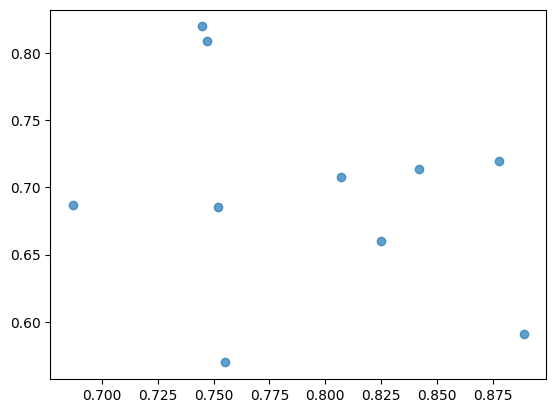

In [59]:
import matplotlib.pyplot as plt

ypred = model1.predict(Xtest)

plt.scatter(ytest, ypred, alpha=0.7)

If the model was accurate I would expect a very tight looking plot that closely resembles the line y = x. This plot DOES NOT represent that, meaning it is likely not very accurate

#### Try a Smaller Training Set?: Repeat the train/test split with only 20% of data as training and 80% as testing. Fit and evaluate your model again. Call this model 'model2'. How's the accuracy now?

In [60]:
Xtrain1, Xtest1, ytrain1, ytest1 = train_test_split(X, y, test_size = 0.8, random_state=0)

print("Xtrain1 shape:", Xtrain1.shape)
print("Xtest1 shape: ", Xtest1.shape)
print("ytrain1 shape:", ytrain1.shape)
print("ytest1 shape: ", ytest1.shape)

Xtrain1 shape: (10, 3)
Xtest1 shape:  (40, 3)
ytrain1 shape: (10,)
ytest1 shape:  (40,)


In [61]:
model2 = LinearRegression(fit_intercept=True)

model2.fit(Xtrain1, ytrain1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
print(model2.coef_)
print(model2.intercept_)

[ 0.10835587 -0.00159585  0.00188856]
0.4529649933838217


The coefficients and intercept are very different from the larger sized training data set

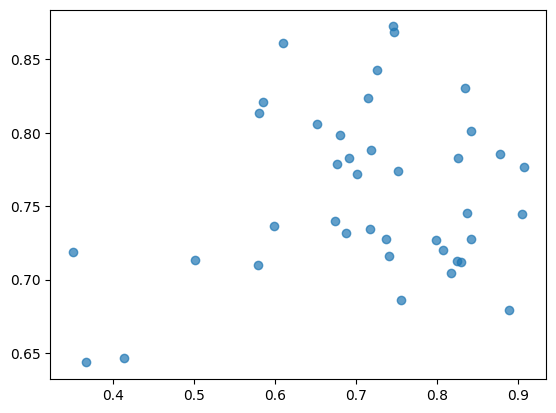

In [63]:
ypred1 = model2.predict(Xtest1)

plt.scatter(ytest1, ypred1, alpha=0.7)

There are more points because the test set is larger now, however it seems to be just as inaccurate as model1. interestingly it seems to be scewed to the right

#### Try More Features: Try using more features (all available numeric ones) in your X. Call this model 'model3'. Re-run the model. What is your accuracy now?

In [64]:
df.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


In [65]:
X3 = df[['energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature']]
y3 = df['danceability']

Xtrain3, Xtest3, ytrain3, ytest3 = train_test_split(X3, y3, test_size = 0.2, random_state=0)

print("Xtrain3 shape:", Xtrain3.shape)
print("Xtest3 shape: ", Xtest3.shape)
print("ytrain3 shape:", ytrain3.shape)
print("ytest3 shape: ", ytest3.shape)

Xtrain3 shape: (40, 12)
Xtest3 shape:  (10, 12)
ytrain3 shape: (40,)
ytest3 shape:  (10,)


In [66]:
model3 = LinearRegression(fit_intercept=True)

model3.fit(Xtrain3, ytrain3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
print(model2.coef_)
print(model2.intercept_)

[ 0.10835587 -0.00159585  0.00188856]
0.4529649933838217


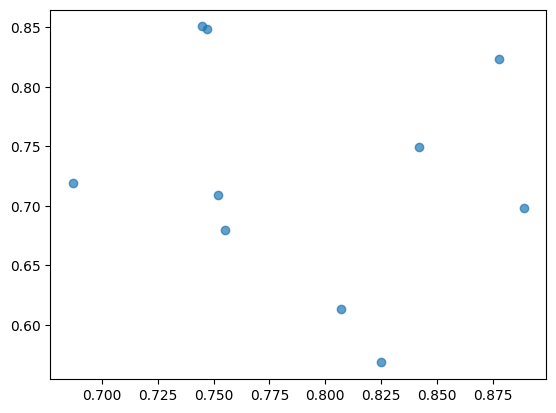

In [68]:
ypred3 = model3.predict(Xtest3)

plt.scatter(ytest3, ypred3, alpha=0.7)

The predictions still look very innacurate and scattered.

acousticness       -0.465118
duration_ms        -0.132798
liveness           -0.088595
mode                0.007662
tempo               0.149066
instrumentalness    0.153419
key                 0.165208
loudness            0.178688
speechiness         0.227283
energy              0.273068
valence             0.391774
danceability        1.000000
time_signature           NaN
Name: danceability, dtype: float64


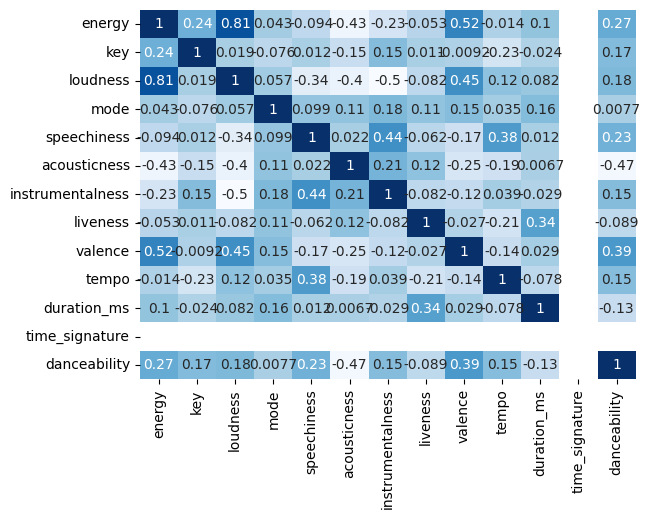

In [69]:
import seaborn as sns

corr_matrix = df[['energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature','danceability']].corr()

sns.heatmap(corr_matrix, annot=True, cbar=False, cmap='Blues')

print(corr_matrix['danceability'].sort_values(ascending=True))

it looks like valence has the highest positice correlation with a value of 0.39 and acousticness has the highest negative correlation of -0.46